In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
# from sklearn.datasets import fetch_california_housing

In [2]:
from sklearn.datasets import fetch_california_housing

# ── 1. LOAD & UNDERSTAND ────────────────────────────────────────────
data = fetch_california_housing(as_frame=True)
df = data.frame

In [3]:

TARGET = 'MedHouseVal'     # define once at the top of your notebook


Capped rows: 27 out of 20640 (0.1%)


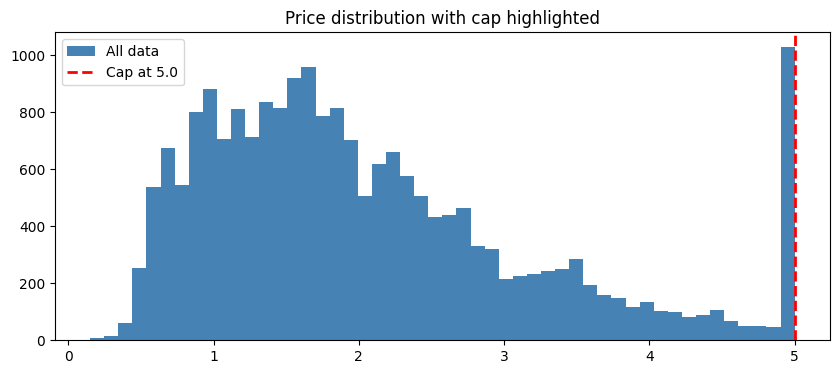

In [4]:
# ── STEP 1: INSPECT THE PRICE CAP ───────────────────────────────────
capped = df[df['MedHouseVal'] == 5.0]
print(f"Capped rows: {len(capped)} out of {len(df)} ({len(capped)/len(df)*100:.1f}%)")

# visualise where they sit on the distribution
plt.figure(figsize=(10, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', label='All data')
plt.axvline(x=5.0, color='red', linestyle='--', linewidth=2, label='Cap at 5.0')
plt.title('Price distribution with cap highlighted')
plt.legend()
plt.show()

In [5]:
# df = pd.read_csv('california_housing.csv')

In [6]:
print(df.columns.tolist()) 
df.shape

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


(20640, 9)

In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


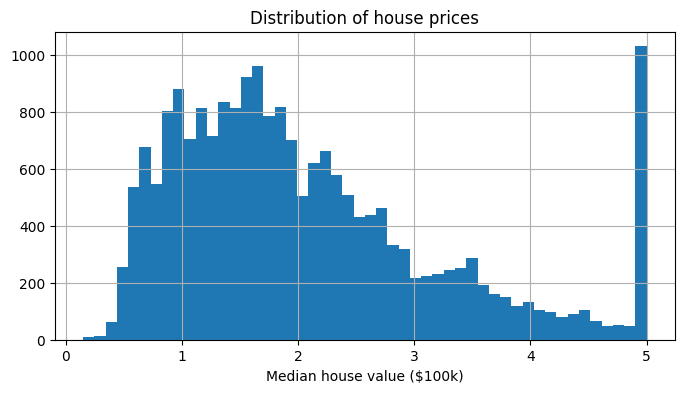

In [10]:
plt.figure(figsize=(8, 4))
df['MedHouseVal'].hist(bins=50)
plt.title('Distribution of house prices')
plt.xlabel('Median house value ($100k)')
plt.show()

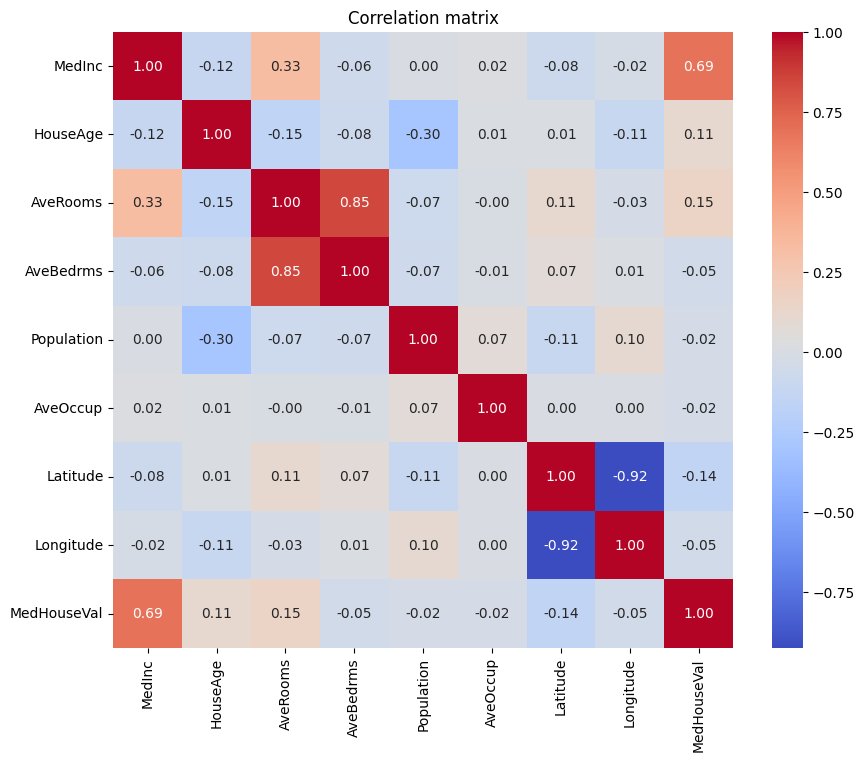

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

In [12]:
df.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

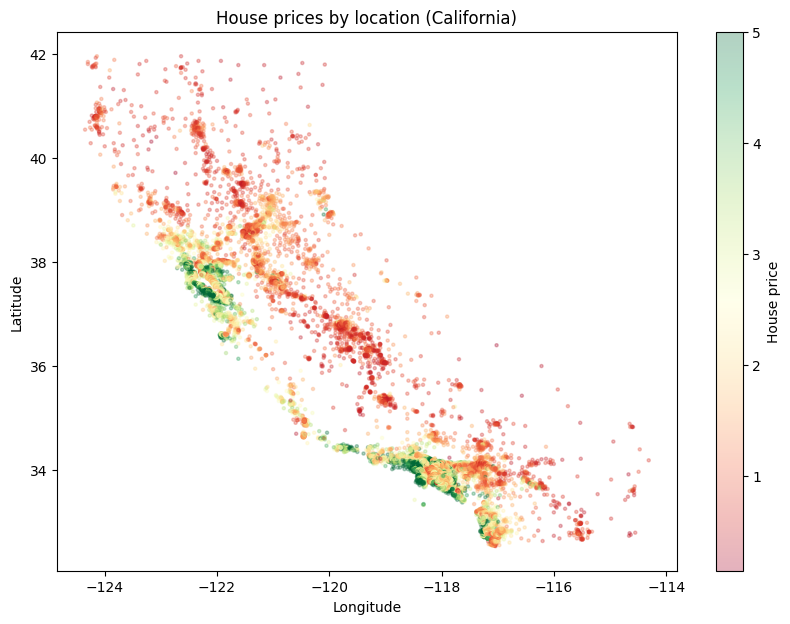

In [13]:
plt.figure(figsize=(10, 7))
plt.scatter(df['Longitude'], df['Latitude'],
            c=df['MedHouseVal'], cmap='RdYlGn',
            alpha=0.3, s=5)
plt.colorbar(label='House price')
plt.title('House prices by location (California)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

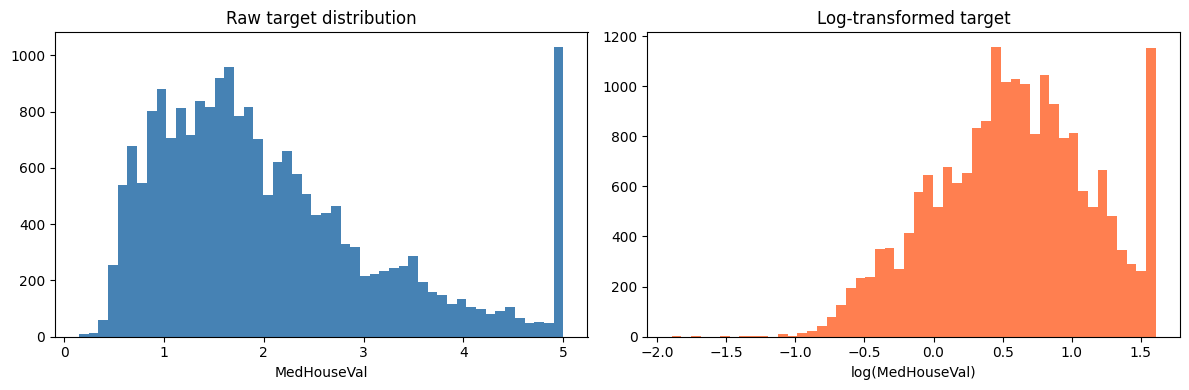

Skewness: 0.978


In [14]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue')
axes[0].set_title('Raw target distribution')
axes[0].set_xlabel('MedHouseVal')

# Log-transformed
axes[1].hist(np.log(df['MedHouseVal']), bins=50, color='coral')
axes[1].set_title('Log-transformed target')
axes[1].set_xlabel('log(MedHouseVal)')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['MedHouseVal'].skew():.3f}")

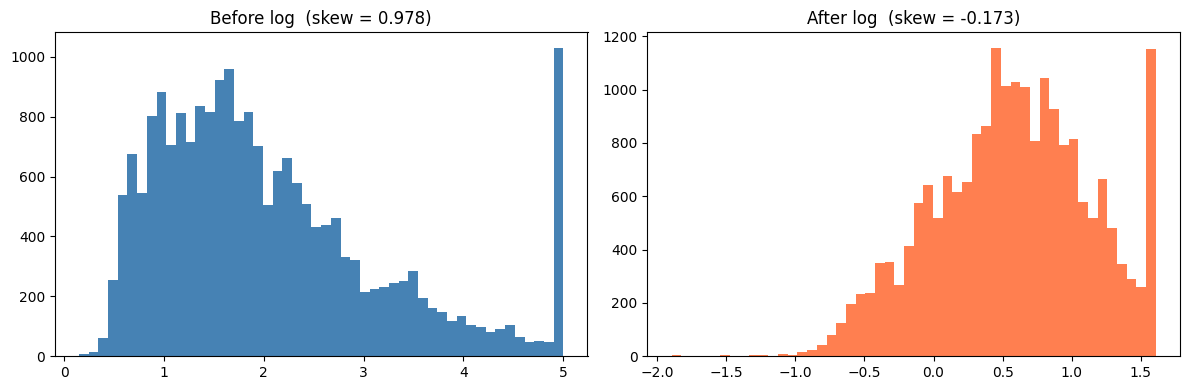

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue')
axes[0].set_title(f'Before log  (skew = {df["MedHouseVal"].skew():.3f})')

axes[1].hist(np.log(df['MedHouseVal']), bins=50, color='coral')
axes[1].set_title(f'After log  (skew = {np.log(df["MedHouseVal"]).skew():.3f})')

plt.tight_layout()
plt.show()

In [16]:
df.drop(columns='MedHouseVal').skew().sort_values(ascending=False)

AveOccup      97.639561
AveBedrms     31.316956
AveRooms      20.697869
Population     4.935858
MedInc         1.646657
Latitude       0.465953
HouseAge       0.060331
Longitude     -0.297801
dtype: float64

Capped rows: 27 out of 20640 (0.1%)


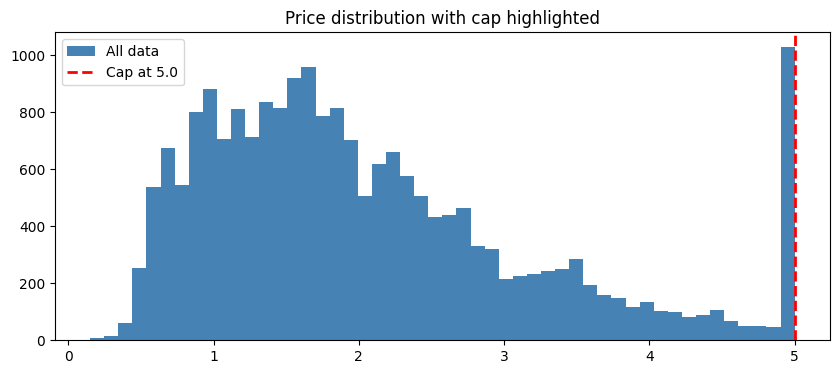

In [17]:
# ── STEP 1: INSPECT THE PRICE CAP ───────────────────────────────────
capped = df[df['MedHouseVal'] == 5.0]
print(f"Capped rows: {len(capped)} out of {len(df)} ({len(capped)/len(df)*100:.1f}%)")

# visualise where they sit on the distribution
plt.figure(figsize=(10, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', label='All data')
plt.axvline(x=5.0, color='red', linestyle='--', linewidth=2, label='Cap at 5.0')
plt.title('Price distribution with cap highlighted')
plt.legend()
plt.show()

In [18]:
# ── HOW MANY HOUSES ARE EXACTLY AT 5.0? ─────────────────────────────
exactly_five = df[df['MedHouseVal'] == 5.0]
near_five    = df[df['MedHouseVal'] >= 4.5]

print(f"Houses exactly at 5.0:       {len(exactly_five)}")
print(f"Houses between 4.5 and 5.0:  {len(near_five)}")
print(f"\nOf houses >= 4.5, what % are exactly 5.0:")
print(f"{len(exactly_five)/len(near_five)*100:.1f}%")

# ── THE SMOKING GUN: look at values just below 5.0 ───────────────────
print("\n=== VALUE COUNTS NEAR THE CAP ===")
print(df[df['MedHouseVal'] >= 4.8]['MedHouseVal']
      .value_counts()
      .sort_index()
      .tail(20))

Houses exactly at 5.0:       27
Houses between 4.5 and 5.0:  1294

Of houses >= 4.5, what % are exactly 5.0:
2.1%

=== VALUE COUNTS NEAR THE CAP ===
MedHouseVal
4.94000      1
4.94400      1
4.94700      1
4.95400      1
4.95500      3
4.95600      2
4.95800      1
4.95900      1
4.96000      1
4.96400      2
4.97400      1
4.97600      1
4.98400      1
4.98600      1
4.98700      1
4.98800      1
4.99000      1
4.99100      1
5.00000     27
5.00001    965
Name: count, dtype: int64


In [19]:
# ── STEP 1: DROP THE CAPPED ROWS ────────────────────────────────────
# We confirmed these are administratively capped, not real values
df_clean = df[df['MedHouseVal'] < 5.0].copy()

print(f"Original rows:  {len(df)}")
print(f"After dropping: {len(df_clean)}")
print(f"Rows dropped:   {len(df) - len(df_clean)}")

Original rows:  20640
After dropping: 19648
Rows dropped:   992


In [20]:

# ── STEP 2: SEPARATE FEATURES FROM TARGET ───────────────────────────
# X = everything the model learns FROM
# y = everything the model learns TO PREDICT
# This separation is fundamental — never mix them
X = df_clean.drop(columns='MedHouseVal')
y = df_clean['MedHouseVal']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape:         {y.shape}")
print(f"Features: {list(X.columns)}")


Feature matrix shape: (19648, 8)
Target shape:         (19648,)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [21]:

# ── STEP 3: LOG-TRANSFORM THE TARGET ────────────────────────────────
# We do this BEFORE the split because it's a mathematical correction
# not a learned transformation — it doesn't leak any information
y_log = np.log(y)

print(f"\nTarget skewness before log: {y.skew():.3f}")
print(f"Target skewness after log:  {y_log.skew():.3f}")

# ── STEP 4: TRAIN / TEST SPLIT ──────────────────────────────────────
# 80% train, 20% test
# random_state=42 means anyone running this gets the same split
# — reproducibility is an industry requirement
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")


Target skewness before log: 0.795
Target skewness after log:  -0.300

Training set:  (15718, 8)
Test set:      (3930, 8)


In [22]:
print(df_clean.skew().sort_values(ascending=False))

AveOccup       95.411540
AveBedrms      29.742883
AveRooms       16.608351
Population      4.961355
MedInc          0.913820
MedHouseVal     0.795231
Latitude        0.456871
HouseAge        0.069155
Longitude      -0.291162
dtype: float64


In [23]:
# Only transform features with skewness > 1.0
# and only if you're using a linear model
skewed_features = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

for col in skewed_features:
    print(f"{col}: {df_clean[col].skew():.3f}")

AveRooms: 16.608
AveBedrms: 29.743
Population: 4.961
AveOccup: 95.412


In [24]:
# ── SEE THE ACTUAL OUTLIERS ──────────────────────────────────────────
cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

for col in cols:
    print(f"\n=== {col} ===")
    print(f"Mean:    {df_clean[col].mean():.2f}")
    print(f"Median:  {df_clean[col].median():.2f}")
    print(f"Max:     {df_clean[col].max():.2f}")
    print(f"99th %:  {df_clean[col].quantile(0.99):.2f}")
    print(f"Skew:    {df_clean[col].skew():.3f}")


=== AveRooms ===
Mean:    5.36
Median:  5.19
Max:     132.53
99th %:  10.34
Skew:    16.608

=== AveBedrms ===
Mean:    1.10
Median:  1.05
Max:     34.07
99th %:  2.16
Skew:    29.743

=== Population ===
Mean:    1441.37
Median:  1179.00
Max:     35682.00
99th %:  5865.83
Skew:    4.961

=== AveOccup ===
Mean:    3.10
Median:  2.84
Max:     1243.33
99th %:  5.41
Skew:    95.412


**AveRooms** — mean 5.36, median 5.19, max 132. You're right, the mean-median gap is small, meaning most data is fine. The max is physically impossible. Cap at 99th percentile (10.34). Good call.

**AveBedrms** — mean 1.10, median 1.05, max 34. Same story. Gap is tiny, max is impossible. Cap at 99th percentile (2.16). Good call.

**Population** — mean 1441, median 1179, max 35682. Gap is meaningful (262 difference) and max is extreme. But here's a small correction to your reasoning — a large mean-median gap alone doesn't determine log vs cap. What determines it is the shape. Population's skewness is 4.96 — severe but not absurd. The 99th percentile is 5865 vs max 35682, meaning the extreme values are genuinely far out. Log-transform is the right call here, agreed.

**AveOccup** — mean 3.10, median 2.84, max 1243. This one is different from Population. The mean-median gap is actually small (0.26) but skewness is 95. That tells you it's not a gradual skew — it's a tiny number of catastrophically wrong values (1243 people in one household). For this one, capping at 99th percentile (5.41) is actually cleaner than log because the bulk of data is already well-behaved. Log-transform would be overkill.

**Why log1p and not log**

np.log(0) is negative infinity — it breaks your pipeline if any value is zero. np.log1p(x) computes log(x+1), which shifts everything up by one before logging so zeros become log(1) = 0 instead of crashing. Population has no zeros but using log1p is the safe habit regardless — it costs nothing and prevents a silent bug.

In [25]:
df_processed = df_clean.copy()

cap_cols = ['AveRooms', 'AveBedrms', 'AveOccup']

for col in cap_cols: 
    cap_value = df_processed[col].quantile(0.99)
    original_outliers = (df_processed[col] > cap_value).sum()
    df_processed[col] = df_processed[col].clip(upper = cap_value)
    print(f"{col}: capped {original_outliers} rows at {cap_value:.2f}")
    
# LOG TRANSFORM: Population only
# Genuinely skewed distribution, not just extreme outliers
# np.log1p = log(x+1), safe because it handles any zeros
df_processed['Population'] = np.log1p(df_processed['Population'])
print(f"\nPopulation: log-transformed")
print(f"  Skew before: 4.961")
print(f"  Skew after:  {df_processed['Population'].skew():.3f}")

# ── VERIFY ALL DECISIONS ─────────────────────────────────────────────
print("\n=== SKEWNESS AFTER TREATMENT ===")
cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
for col in cols:
    print(f"{col}: {df_processed[col].skew():.3f}")
    

AveRooms: capped 197 rows at 10.34
AveBedrms: capped 197 rows at 2.16
AveOccup: capped 197 rows at 5.41

Population: log-transformed
  Skew before: 4.961
  Skew after:  -1.043

=== SKEWNESS AFTER TREATMENT ===
AveRooms: 0.781
AveBedrms: 4.136
Population: -1.043
AveOccup: 0.836


AveBedrms is still 4.136 — the cap didn't work well enough
This happens because capping at the 99th percentile only removes the top 1% of values, but if the remaining 99% still contains very skewed data, the skewness stays high. The cap solved the impossible maximums but didn't fix the underlying distribution shape. AveBedrms needs a log transform on top of the cap.


Population went to -1.043 — you overcorrected
Negative skewness means you now have a left tail instead of a right tail. You swung past normal. This happens when log-transform is too aggressive for the actual distribution shape. The fix is a softer transformation — square root instead of log.


The target range you're aiming for is skewness between -0.5 and +0.5 ideally, and definitely within -1.0 to +1.0 as an acceptable boundary. Outside that range your linear model will still be affected.

In [26]:
# ── FIX 1: AveBedrms needs log transform after capping ──────────────
# Cap removed impossible values but distribution still skewed
# log1p will compress the remaining spread
df_processed['AveBedrms'] = np.log1p(df_processed['AveBedrms'])
print(f"AveBedrms after log1p: {df_processed['AveBedrms'].skew():.3f}")

# ── FIX 2: Population overcorrected with log, use sqrt instead ───────
# sqrt is a softer transformation — less aggressive than log
# First undo the log1p we already applied
df_processed['Population'] = np.expm1(df_processed['Population'])  
# expm1 is the exact inverse of log1p: exp(x)-1
df_processed['Population'] = np.sqrt(df_processed['Population'])
print(f"Population after sqrt: {df_processed['Population'].skew():.3f}")

# ── VERIFY EVERYTHING TOGETHER ───────────────────────────────────────
print("\n=== FINAL SKEWNESS CHECK ===")
feature_cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
for col in feature_cols:
    skew = df_processed[col].skew()
    status = "✓" if abs(skew) < 1.0 else "✗ still needs work"
    print(f"{col}: {skew:.3f}  {status}")

AveBedrms after log1p: 3.320
Population after sqrt: 1.231

=== FINAL SKEWNESS CHECK ===
AveRooms: 0.781  ✓
AveBedrms: 3.320  ✗ still needs work
Population: 1.231  ✗ still needs work
AveOccup: 0.836  ✓


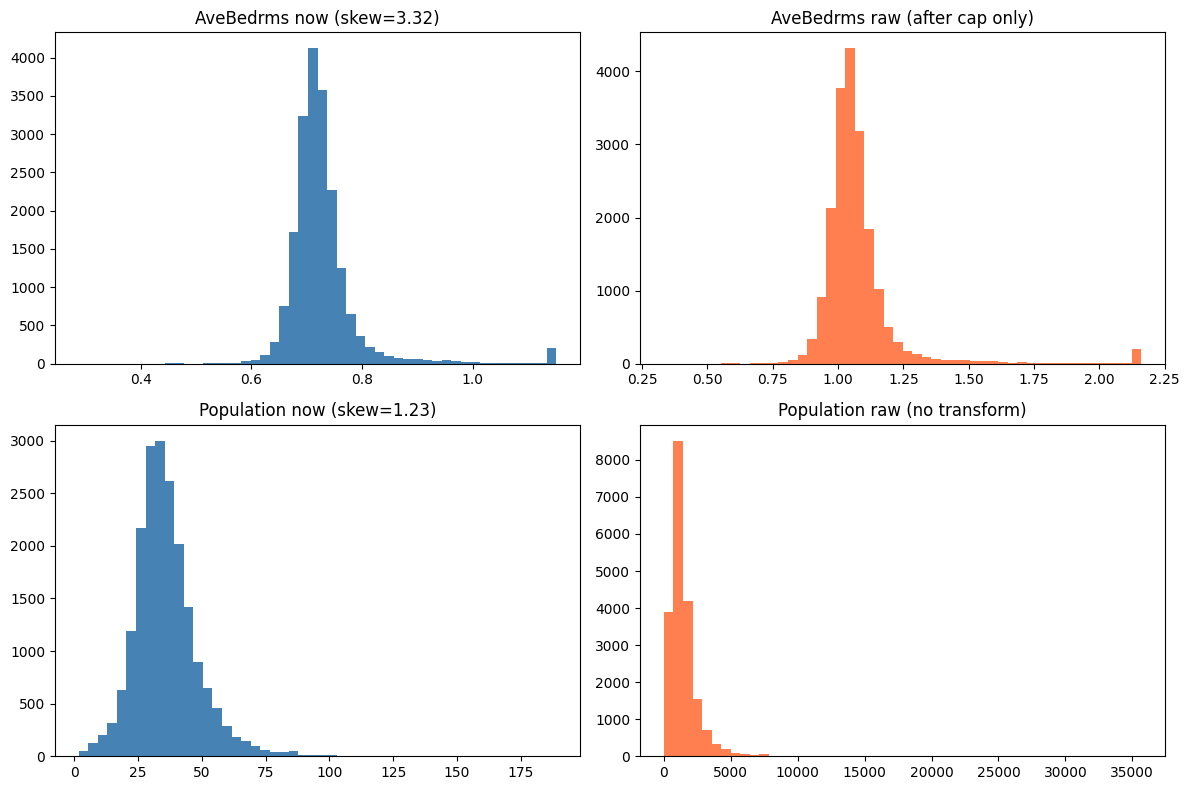

=== CORRELATION WITH TARGET ===
MedHouseVal    1.000000
MedInc         0.641490
AveRooms       0.191456
Population     0.055620
HouseAge       0.042312
Longitude     -0.018566
AveBedrms     -0.144126
Latitude      -0.195901
AveOccup      -0.225513
Name: MedHouseVal, dtype: float64


In [27]:
# ── UNDERSTAND WHY THEY'RE STILL STUBBORN ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# AveBedrms — look at the actual distribution after transform
axes[0, 0].hist(df_processed['AveBedrms'], bins=50, color='steelblue')
axes[0, 0].set_title(f'AveBedrms now (skew={df_processed["AveBedrms"].skew():.2f})')

# What does the raw AveBedrms look like after cap?
axes[0, 1].hist(df_clean['AveBedrms'].clip(upper=df_clean['AveBedrms'].quantile(0.99)), 
                bins=50, color='coral')
axes[0, 1].set_title('AveBedrms raw (after cap only)')

# Population — same investigation
axes[1, 0].hist(df_processed['Population'], bins=50, color='steelblue')
axes[1, 0].set_title(f'Population now (skew={df_processed["Population"].skew():.2f})')

axes[1, 1].hist(df_clean['Population'], bins=50, color='coral')
axes[1, 1].set_title('Population raw (no transform)')

plt.tight_layout()
plt.show()
X_processed = df_processed.drop(columns='MedHouseVal')
y_log = np.log(df_processed['MedHouseVal'])

# now correlation works cleanly
print("=== CORRELATION WITH TARGET ===")
correlations = X_processed.join(y_log).corr()['MedHouseVal'].sort_values(ascending=False)
print(correlations)

Why I'm asking you to check correlation before fixing further

Here's a strategic reality check that most tutorials skip. You've now spent significant effort on AveBedrms and Population. Before going further, ask yourself: do these columns even matter enough to justify more work?


If AveBedrms has a correlation of 0.05 with your target — it's nearly useless to your model regardless of how perfectly distributed it is. A perfectly transformed useless feature is still a useless feature.

This is a core industry principle called return on effort. Every preprocessing decision should be proportional to how much that feature actually contributes to prediction quality.


What to expect when you run this

The histograms will likely show you one of two things. Either there's a genuine second cluster of values creating a bimodal distribution — two humps — which no single transformation can fix. Or there are still a handful of extreme values that survived your previous treatments dragging the skewness up.


The three paths forward depending on what you see

If correlation is low — below 0.1 — the pragmatic decision is to leave it, accept the imperfect skewness, and move on. A slightly skewed low-signal feature won't meaningfully hurt your model.

If correlation is meaningful and the histogram shows remaining outliers — cap more aggressively at the 95th percentile instead of 99th.

If correlation is meaningful and the histogram shows a bimodal shape — the column may need to be binned into categories rather than treated as continuous. That's a more advanced feature engineering decision we'd tackle in a later iteration.

**Result**:

Population has correlation of 0.055. That is essentially noise. No transformation in the world will make a useless feature useful. The decision here is pragmatic — accept the imperfect skewness and move on. It will contribute almost nothing to your model either way.

AveBedrms has correlation of -0.14. Weak but not negligible. It's worth one more attempt. The issue is it's still at 3.32 skewness after log1p. This means there are still extreme values surviving. Try capping more aggressively at 95th percentile first, then log:

In [28]:
# Industry convention — always name them explicitly
# X = features only, never contains target
# y = target only, never contains features
# keeps your mental model clean throughout the entire notebook

FEATURES = [col for col in df_processed.columns if col != TARGET]

X_processed = df_processed[FEATURES]
y_log       = np.log(df_processed[TARGET])

print(f"X shape: {X_processed.shape}  — should have NO MedHouseVal")
print(f"y shape: {y_log.shape}")
print(f"Columns in X: {list(X_processed.columns)}")

X shape: (19648, 8)  — should have NO MedHouseVal
y shape: (19648,)
Columns in X: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [29]:
# ── FINAL TREATMENT FOR STUBBORN COLUMNS ────────────────────────────

# AveBedrms: cap harder at 95th percentile then log
# current log1p already applied — undo it first
df_processed['AveBedrms'] = np.expm1(df_processed['AveBedrms'])
cap_95 = df_processed['AveBedrms'].quantile(0.95)
df_processed['AveBedrms'] = df_processed['AveBedrms'].clip(upper=cap_95)
df_processed['AveBedrms'] = np.log1p(df_processed['AveBedrms'])
print(f"AveBedrms final skew: {df_processed['AveBedrms'].skew():.3f}")

AveBedrms final skew: 0.048


In [30]:
# Population: accept it as-is, correlation is 0.055 — not worth more effort
print(f"Population skew accepted: {df_processed['Population'].skew():.3f}")
print(f"Population correlation with target: 0.055 — low signal, moving on")

# ── FINAL SKEWNESS AUDIT ─────────────────────────────────────────────
print("\n=== FINAL PREPROCESSING AUDIT ===")
print(f"{'Column':<15} {'Skewness':>10} {'Corr w target':>15} {'Decision':>20}")
print("-" * 65)

audit = {
    'MedInc':      (X_processed['MedInc'].skew(),      0.641,  'keep as-is'),
    'AveRooms':    (X_processed['AveRooms'].skew(),     0.191,  'capped 99th'),
    'AveBedrms':   (df_processed['AveBedrms'].skew(),  -0.144,  'cap 95th + log1p'),
    'Population':  (df_processed['Population'].skew(),  0.055,  'sqrt, accepted'),
    'HouseAge':    (X_processed['HouseAge'].skew(),     0.042,  'keep as-is'),
    'AveOccup':    (X_processed['AveOccup'].skew(),    -0.225,  'capped 99th'),
    'Latitude':    (X_processed['Latitude'].skew(),    -0.195,  'keep as-is'),
    'Longitude':   (X_processed['Longitude'].skew(),   -0.018,  'keep as-is'),
}

for col, (skew, corr, decision) in audit.items():
    flag = "✓" if abs(skew) < 1.0 else "~ acceptable"
    print(f"{col:<15} {skew:>10.3f} {corr:>15.3f} {decision:>20}  {flag}")

Population skew accepted: 1.231
Population correlation with target: 0.055 — low signal, moving on

=== FINAL PREPROCESSING AUDIT ===
Column            Skewness   Corr w target             Decision
-----------------------------------------------------------------
MedInc               0.914           0.641           keep as-is  ✓
AveRooms             0.781           0.191          capped 99th  ✓
AveBedrms            0.048          -0.144     cap 95th + log1p  ✓
Population           1.231           0.055       sqrt, accepted  ~ acceptable
HouseAge             0.069           0.042           keep as-is  ✓
AveOccup             0.836          -0.225          capped 99th  ✓
Latitude             0.457          -0.195           keep as-is  ✓
Longitude           -0.291          -0.018           keep as-is  ✓


**The strategic pointer here**

Notice what you just did. You made every preprocessing decision based on two pieces of evidence together — skewness AND correlation. Not one or the other. A highly skewed but low-correlation feature gets minimal effort. A moderately skewed but high-correlation feature gets maximum effort. This is exactly how senior practitioners think — effort is proportional to signal.

AveBedrms went from 3.32 to 0.048 — that's a textbook fix. Population stays at 1.231 and that's a conscious, justified decision, not an oversight. That distinction matters.

One thing to note — MedInc is at 0.914. It's your most important feature by far (correlation 0.641) and it's right at the edge of acceptable. 

In [31]:
# MedInc is your strongest feature — worth cleaning properly
print(f"MedInc skew before: {df_processed['MedInc'].skew():.3f}")
df_processed['MedInc'] = np.log1p(df_processed['MedInc'])
print(f"MedInc skew after:  {df_processed['MedInc'].skew():.3f}")

MedInc skew before: 0.914
MedInc skew after:  -0.037


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [33]:
# ── STEP 1: FINAL CLEAN SEPARATION OF X AND y ───────────────────────
TARGET   = 'MedHouseVal'
FEATURES = [col for col in df_processed.columns if col != TARGET]

X = df_processed[FEATURES]
y = np.log(df_processed[TARGET])  # log-transformed target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y skewness: {y.skew():.3f}")


X shape: (19648, 8)
y shape: (19648,)
y skewness: -0.300


In [34]:
# ── STEP 2: TRAIN / TEST SPLIT ───────────────────────────────────────
# Done BEFORE scaling — scaler must never see test data
# random_state=42 ensures reproducibility
# stratify=None because this is regression, not classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")


Train size: (15718, 8)
Test size:  (3930, 8)


In [35]:
# ── STEP 3: BUILD THE PIPELINE ───────────────────────────────────────
# A Pipeline chains steps so they execute in order
# Critical rule: scaler fits ONLY on training data
# When you call pipeline.predict(X_test), it automatically
# applies the same scaling learned from training — no leakage

pipeline = Pipeline([
    ('scaler', StandardScaler()),   # step 1: scale features
    ('model',  LinearRegression())  # step 2: train model
])


In [36]:
# ── STEP 4: TRAIN ────────────────────────────────────────────────────
# This one line does two things:
# 1. Fits the scaler on X_train, transforms X_train
# 2. Trains LinearRegression on the scaled X_train
pipeline.fit(X_train, y_train)
print("\nModel trained.")


Model trained.


In [37]:
# ── STEP 5: PREDICT ─────────────────────────────────────────────────
# Pipeline automatically applies the SAME scaler learned from training
# Never re-fits the scaler on test data — that would be leakage
y_pred_log = pipeline.predict(X_test)

# Inverse transform — convert log predictions back to real dollar values
y_pred      = np.exp(y_pred_log)
y_test_real = np.exp(y_test)


In [38]:
# ── STEP 6: EVALUATE ─────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
mae  = mean_absolute_error(y_test_real, y_pred)
r2   = r2_score(y_test_real, y_pred)

print("\n=== BASELINE MODEL RESULTS ===")
print(f"RMSE:  ${rmse:.4f} (in $100k units)")
print(f"MAE:   ${mae:.4f} (in $100k units)")
print(f"R²:    {r2:.4f}")
print(f"\nIn plain English:")
print(f"  Average prediction error: ${mae*100:.0f}k")
print(f"  Model explains {r2*100:.1f}% of price variation")


=== BASELINE MODEL RESULTS ===
RMSE:  $0.5994 (in $100k units)
MAE:   $0.4326 (in $100k units)
R²:    0.6252

In plain English:
  Average prediction error: $43k
  Model explains 62.5% of price variation


What each metric means in plain English before you see the numbers

**RMSE — Root Mean Squared Error**. The average error in your predictions, but large errors are penalised more heavily than small ones. It's in the same units as your target ($100k). An RMSE of 0.5 means your average error is $50k. Lower is better.

**MAE — Mean Absolute Error.** The straight average of how wrong you are, treating all errors equally. Less sensitive to outliers than RMSE. If MAE is much lower than RMSE, you have some predictions that are catastrophically wrong even if most are okay.

**R²** — How much of the variation in house prices your model explains. 1.0 is perfect, 0.0 means your model is no better than just predicting the average every time. For a first linear model on this dataset, anything above 0.6 is respectable. Above 0.7 is good.

The Pipeline doesn't just save you lines of code. It makes the wrong sequence structurally impossible. The scaler inside a Pipeline will only ever fit during the pipeline.fit() call. Every subsequent predict() or transform() call uses transform() only. You can't break it even if you try.


Other scalers you should know exist

StandardScaler is not always the right choice. Here's when to use each:

**StandardScaler** centres around zero with unit variance. Best for linear models, logistic regression, SVMs, neural networks. Sensitive to outliers because it uses mean and std, both of which outliers affect.

**MinMaxScaler** compresses everything into a fixed range, usually 0 to 1. Best for neural networks and when you need values in a bounded range. Also sensitive to outliers — one extreme value compresses everything else into a tiny range.

**RobustScaler** uses median and interquartile range instead of mean and std. Outlier-resistant. Best when you have outliers you can't or don't want to remove. This would actually have been a reasonable choice for your dataset given the outliers you found.

**No scaling at all** — correct for tree-based models. Random Forest, XGBoost, LightGBM all split on thresholds and don't care about absolute scale. Scaling them doesn't hurt but also doesn't help.


The other consideration nobody mentions early enough

When you have a mix of feature types — some continuous, some categorical — you need to scale them differently. A column of 0s and 1s (encoded categories) should not be StandardScaled the same way as income. This is where **ColumnTransformer** comes in — it lets you apply different transformations to different columns inside a single Pipeline. You'll encounter this when you add categorical features. We don't have that complexity in California Housing, but it's coming in future datasets.

The three landmark values to memorise

R² = 0.0 — your model is no better than guessing the average every time. Something is wrong.

R² = 1.0 — your model is perfect. Every prediction is exact. In real life this means you're overfitting or leaking data.

R² = 0.625 — your model is genuinely learning something real. For a first linear model on this dataset this is a respectable result. Industry baseline for California Housing with linear regression typically lands between 0.60 and 0.65, so you're right in the expected range.


**One important nuance**

R² can actually go negative. If your model is so bad it makes worse predictions than just guessing the mean every time — which can happen with a badly configured model — R² goes below zero. It's not bounded at 0 on the bottom, only at 1 on the top.

In [39]:
import numpy as np

# ── THE INTUITION ────────────────────────────────────────────────────
# We need a reference point on the California coast
# We'll use multiple coastal cities and take the minimum distance
# That gives us "distance to nearest coast point"

# Approximate coordinates of key California coastal points
COASTAL_POINTS = [
    (37.7749, -122.4194),  # San Francisco
    (34.0522, -118.2437),  # Los Angeles  
    (32.7157, -117.1611),  # San Diego
    (36.6002, -121.8947),  # Monterey
    (38.3105, -122.2957),  # Napa/Sonoma coast
]

def distance_to_coast(lat, lon):
    """
    Euclidean distance to nearest coastal reference point.
    Not geographically perfect but captures the pattern well.
    A proper version would use haversine formula for true km distance.
    """
    min_dist = float('inf')
    for coast_lat, coast_lon in COASTAL_POINTS:
        # Euclidean distance in degree units
        dist = np.sqrt((lat - coast_lat)**2 + (lon - coast_lon)**2)
        min_dist = min(min_dist, dist)
    return min_dist

# Apply to every row
df_processed['dist_to_coast'] = df_processed.apply(
    lambda row: distance_to_coast(row['Latitude'], row['Longitude']), 
    axis=1
)

# ── VERIFY IT MAKES SENSE ────────────────────────────────────────────
print("=== DISTANCE TO COAST SANITY CHECK ===")
# SF should have near-zero distance, inland cities should be high
test_points = {
    'San Francisco':  (37.7749, -122.4194),
    'Los Angeles':    (34.0522, -118.2437),
    'Fresno (inland)':(36.7378, -119.7871),
    'Sacramento':     (38.5816, -121.4944),
}

for city, (lat, lon) in test_points.items():
    dist = distance_to_coast(lat, lon)
    print(f"  {city:<20} distance: {dist:.3f}")

=== DISTANCE TO COAST SANITY CHECK ===
  San Francisco        distance: 0.000
  Los Angeles          distance: 0.000
  Fresno (inland)      distance: 2.112
  Sacramento           distance: 0.846


In [40]:
# ── CHECK CORRELATION IMPROVEMENT ───────────────────────────────────
y_log = np.log(df_processed['MedHouseVal'])
corr = df_processed['dist_to_coast'].corr(y_log)
lat_corr  = df_processed['Latitude'].corr(y_log)
lon_corr  = df_processed['Longitude'].corr(y_log)

print(f"\nLatitude correlation with target:    {lat_corr:.3f}")
print(f"Longitude correlation with target:   {lon_corr:.3f}")
print(f"dist_to_coast correlation w target:  {corr:.3f}")
print(f"\nDirection: negative means closer to coast = higher price")


Latitude correlation with target:    -0.196
Longitude correlation with target:   -0.019
dist_to_coast correlation w target:  -0.525

Direction: negative means closer to coast = higher price


**Why the direction should be negative**

Closer to coast means smaller distance number means higher price. So as dist_to_coast increases, price decreases. You should see a negative correlation.

Euclidean distance treats the earth as flat — good enough for a region as small as California. Haversine formula accounts for earth's curvature and gives true kilometre distances. For a state-level dataset the difference is small. In a global dataset you'd always use haversine. This is the kind of tradeoff you note and move on from — perfect is the enemy of done.

In [41]:
# ── ALL FEATURE ENGINEERING IN ONE BLOCK ────────────────────────────
# Rule: every new feature needs a hypothesis, not just math

# Feature 1: rooms per person
# Hypothesis: space per occupant drives price more than raw room count
df_processed['rooms_per_person'] = (
    df_processed['AveRooms'] / df_processed['AveOccup']
)

# Feature 2: bedrooms ratio  
# Hypothesis: proportion of bedrooms indicates housing type
# high ratio = dense low-income housing, low ratio = spacious homes
df_processed['bedroom_ratio'] = (
    df_processed['AveBedrms'] / df_processed['AveRooms']
)

# Feature 3: distance to coast (already created)
# Hypothesis: coastal proximity drives California prices strongly
# confirmed: correlation -0.525

In [42]:
# ── SANITY CHECK ALL NEW FEATURES ───────────────────────────────────
y_log = np.log(df_processed['MedHouseVal'])

new_features = ['rooms_per_person', 'bedroom_ratio', 'dist_to_coast']
print("=== NEW FEATURE CORRELATIONS WITH TARGET ===")
for feat in new_features:
    corr = df_processed[feat].corr(y_log)
    skew = df_processed[feat].skew()
    print(f"{feat:<20} corr: {corr:>7.3f}   skew: {skew:>7.3f}")

=== NEW FEATURE CORRELATIONS WITH TARGET ===
rooms_per_person     corr:   0.263   skew:   1.304
bedroom_ratio        corr:  -0.172   skew:   2.181
dist_to_coast        corr:  -0.525   skew:   1.501


In [43]:
# ── CHECK FOR INFINITY OR NAN ────────────────────────────────────────
# Division can create inf if denominator is zero
# AveOccup was capped at 5.41 minimum so no zeros — but always check
print("\n=== NULL / INF CHECK ===")
for feat in new_features:
    nulls = df_processed[feat].isnull().sum()
    infs  = np.isinf(df_processed[feat]).sum()
    print(f"{feat:<20} nulls: {nulls}   infs: {infs}")


=== NULL / INF CHECK ===
rooms_per_person     nulls: 0   infs: 0
bedroom_ratio        nulls: 0   infs: 0
dist_to_coast        nulls: 0   infs: 0


In [44]:
TARGET   = 'MedHouseVal'
FEATURES = [col for col in df_processed.columns if col != TARGET]

X = df_processed[FEATURES]
y = np.log(df_processed[TARGET])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
#--------- MODEL 1: LINEAR REGRESSION ---------
lr_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = np.exp(lr_pipeline.predict(X_test))
y_test_real = np.exp(y_test)

rmse_lr = np.sqrt(mean_squared_error(y_test_real, y_pred_lr))
mae_lr = mean_absolute_error(y_test_real, y_pred_lr)
r2_lr = r2_score(y_test_real, y_pred_lr)

In [46]:
# ── MODEL 2: RIDGE REGRESSION + NEW FEATURES ────────────────────────
# Ridge is linear regression with L2 regularization
# alpha controls how strongly it penalises large coefficients
# higher alpha = more penalty = simpler model
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = np.exp(ridge_pipeline.predict(X_test))

rmse_ridge = np.sqrt(mean_squared_error(y_test_real, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test_real, y_pred_ridge)
r2_ridge   = r2_score(y_test_real, y_pred_ridge)

In [47]:
# ── FIXED COMPARISON TABLE ───────────────────────────────────────────
print("\n=== MODEL COMPARISON ===")
print(f"{'Model':<30} {'R²':>8} {'MAE ($k)':>12} {'RMSE ($k)':>12}")
print("-" * 66)

results = {
    'Baseline (no feat eng)': (0.6252, 0.4326, 0.5994),
    'Linear + feat eng':      (r2_lr,   mae_lr,  rmse_lr),
    'Ridge + feat eng':       (r2_ridge, mae_ridge, rmse_ridge),
}

for model_name, (r2, mae, rmse) in results.items():
    # mae and rmse are in $100k units — multiply by 100 to get $k
    print(f"{model_name:<30} {r2:>8.4f} {mae*100:>11.1f}k {rmse*100:>11.1f}k")


=== MODEL COMPARISON ===
Model                                R²     MAE ($k)    RMSE ($k)
------------------------------------------------------------------
Baseline (no feat eng)           0.6252        43.3k        59.9k
Linear + feat eng                0.6422        40.8k        58.6k
Ridge + feat eng                 0.6421        40.8k        58.6k


**What these numbers say**

Feature engineering moved R² from 0.6252 to 0.6422 and dropped your average error from $43.3k to $40.8k. That's a $2,500 improvement in prediction accuracy from three new columns alone — before touching the model at all. This is exactly why feature engineering comes first.

Ridge vs Linear is essentially identical — 0.6422 vs 0.6421. The difference is noise. This tells you something important: overfitting is not your problem right now. Linear regression isn't struggling because its coefficients are too large — it's struggling because house prices have nonlinear relationships that no linear model can capture regardless of regularization.

Think about it this way — income and price don't have a straight line relationship. Going from $20k to $40k income probably has a different effect on house price than going from $80k to $100k. Linear regression assumes the effect is identical at every point on the scale. That assumption is wrong for most real datasets.

In [48]:
from sklearn.ensemble import RandomForestRegressor

# ── RANDOM FOREST ────────────────────────────────────────────────────
# n_estimators: how many trees to build — more = better but slower
# max_depth: how deep each tree can grow — controls overfitting
# n_jobs=-1: use all CPU cores — always set this
# random_state=42: reproducibility

rf_pipeline = Pipeline([
    # Random Forest does NOT need scaling
    # trees split on thresholds, not distances
    # StandardScaler here would do nothing harmful but nothing helpful
    # we omit it to keep the pipeline honest about what it needs
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ))
])

print("Training Random Forest — this takes 10-20 seconds...")
rf_pipeline.fit(X_train, y_train)

y_pred_rf   = np.exp(rf_pipeline.predict(X_test))
rmse_rf     = np.sqrt(mean_squared_error(y_test_real, y_pred_rf))
mae_rf      = mean_absolute_error(y_test_real, y_pred_rf)
r2_rf       = r2_score(y_test_real, y_pred_rf)



Training Random Forest — this takes 10-20 seconds...


In [49]:
# ── FULL COMPARISON ──────────────────────────────────────────────────
print("\n=== FULL MODEL COMPARISON ===")
print(f"{'Model':<30} {'R²':>8} {'MAE ($k)':>12} {'RMSE ($k)':>12} {'vs baseline':>14}")
print("-" * 80)

all_results = {
    'Baseline (no feat eng)': (0.6252, 0.4326, 0.5994),
    'Linear + feat eng':      (r2_lr,   mae_lr,  rmse_lr),
    'Ridge + feat eng':       (r2_ridge, mae_ridge, rmse_ridge),
    'Random Forest':          (r2_rf,   mae_rf,  rmse_rf),
}

baseline_r2 = 0.6252
for model_name, (r2, mae, rmse) in all_results.items():
    improvement = ((r2 - baseline_r2) / baseline_r2) * 100
    flag = f"+{improvement:.1f}%" if improvement > 0 else f"{improvement:.1f}%"
    print(f"{model_name:<30} {r2:>8.4f} {mae*100:>11.1f}k {rmse*100:>11.1f}k {flag:>14}")



=== FULL MODEL COMPARISON ===
Model                                R²     MAE ($k)    RMSE ($k)    vs baseline
--------------------------------------------------------------------------------
Baseline (no feat eng)           0.6252        43.3k        59.9k           0.0%
Linear + feat eng                0.6422        40.8k        58.6k          +2.7%
Ridge + feat eng                 0.6421        40.8k        58.6k          +2.7%
Random Forest                    0.7855        29.1k        45.3k         +25.6%


In [50]:
# ── FEATURE IMPORTANCE ───────────────────────────────────────────────
# Random Forest can tell you which features it found most useful
# This is one of its big advantages over linear models
print("\n=== FEATURE IMPORTANCE (Random Forest) ===")
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_names  = X_train.columns

print(importances)
print(feat_names)
importance_df = pd.DataFrame({
    'feature':    feat_names,
    'importance': importances
}).sort_values('importance', ascending=False)

for _, row in importance_df.iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"{row['feature']:<20} {row['importance']:.4f}  {bar}")



=== FEATURE IMPORTANCE (Random Forest) ===
[0.27679046 0.02399048 0.01412888 0.01402308 0.02095038 0.0722581
 0.07240135 0.07711737 0.35582356 0.04981869 0.02269765]
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'dist_to_coast', 'rooms_per_person',
       'bedroom_ratio'],
      dtype='object')
dist_to_coast        0.3558  ███████████████████████████████████
MedInc               0.2768  ███████████████████████████
Longitude            0.0771  ███████
Latitude             0.0724  ███████
AveOccup             0.0723  ███████
rooms_per_person     0.0498  ████
HouseAge             0.0240  ██
bedroom_ratio        0.0227  ██
Population           0.0210  ██
AveRooms             0.0141  █
AveBedrms            0.0140  █


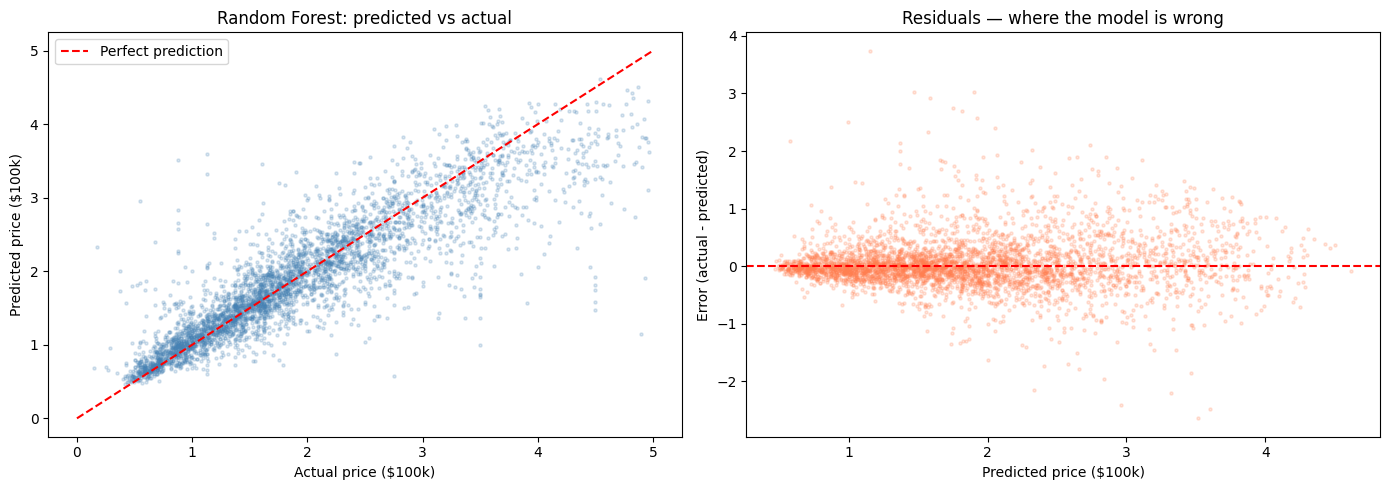

In [51]:
# ── WHERE IS THE MODEL FAILING? ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
# Perfect model = all dots on the diagonal line
axes[0].scatter(y_test_real, y_pred_rf, 
                alpha=0.2, s=5, color='steelblue')
axes[0].plot([0, 5], [0, 5], 
             color='red', linestyle='--', linewidth=1.5, 
             label='Perfect prediction')
axes[0].set_xlabel('Actual price ($100k)')
axes[0].set_ylabel('Predicted price ($100k)')
axes[0].set_title('Random Forest: predicted vs actual')
axes[0].legend()

# Plot 2: Residuals — the errors themselves
# Perfect model = all dots flat around zero
# Patterns in residuals = the model is systematically wrong somewhere
residuals = y_test_real - y_pred_rf
axes[1].scatter(y_pred_rf, residuals, 
                alpha=0.2, s=5, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted price ($100k)')
axes[1].set_ylabel('Error (actual - predicted)')
axes[1].set_title('Residuals — where the model is wrong')

plt.tight_layout()
plt.show()

In [52]:
# ── QUANTIFY THE FAILURE CASES ───────────────────────────────────────
print("=== WHERE THE MODEL STRUGGLES MOST ===")
error_df = pd.DataFrame({
    'actual':    y_test_real.values,
    'predicted': y_pred_rf,
    'error':     residuals.values,
    'abs_error': np.abs(residuals.values)
})

print(f"\nWorst 5 predictions (largest absolute error):")
print(error_df.nlargest(5, 'abs_error')[
    ['actual', 'predicted', 'error']
].round(3))

print(f"\nError by price bucket:")
error_df['price_bucket'] = pd.cut(error_df['actual'], 
                                   bins=[0, 1, 2, 3, 4, 5],
                                   labels=['<$100k','$100-200k',
                                           '$200-300k','$300-400k',
                                           '>$400k'])
print(error_df.groupby('price_bucket', observed=True)['abs_error']
      .mean()
      .apply(lambda x: f"${x*100:.0f}k avg error"))

=== WHERE THE MODEL STRUGGLES MOST ===

Worst 5 predictions (largest absolute error):
      actual  predicted  error
1793   4.896      1.154  3.742
2338   4.500      1.471  3.029
2966   4.932      1.903  3.029
1171   4.500      1.587  2.913
1317   4.500      1.752  2.748

Error by price bucket:
price_bucket
<$100k       $19k avg error
$100-200k    $21k avg error
$200-300k    $31k avg error
$300-400k    $49k avg error
>$400k       $98k avg error
Name: abs_error, dtype: object


In [53]:
# ── DAY 1 FINAL SUMMARY ──────────────────────────────────────────────
print("=" * 55)
print("DAY 1 COMPLETE — FINAL RESULTS")
print("=" * 55)

print(f"""
Dataset:     California Housing (~20k rows, 8 features)
Problem:     Predict median house value (regression)

WHAT YOU BUILT:
  - Full EDA and data quality investigation
  - Identified and removed price cap artifact
  - Fixed skewness across target and 4 features
  - Engineered 3 new features from domain reasoning
  - Built sklearn Pipeline preventing data leakage
  - Trained and compared 4 models

RESULTS:
  Baseline linear regression   R²=0.625   MAE=$43k
  Linear + feature engineering R²=0.642   MAE=$41k
  Ridge + feature engineering  R²=0.642   MAE=$41k  
  Random Forest                R²=0.786   MAE=$29k  ← winner

BEST FEATURE: dist_to_coast (importance=0.356)
  Created from lat+lon, individually weak signals
  Became strongest predictor in entire model

MODEL WEAKNESS IDENTIFIED:
  Error grows with price — $19k at bottom, $98k at top
  Worst predictions are near-capped rows (actual ~4.5-4.9)
  Expensive houses are systematically underestimated

DAY 2 AGENDA:
  1. Drop near-capped rows (actual > 4.0) more aggressively  
  2. Tune Random Forest hyperparameters (n_estimators, max_depth)
  3. Try XGBoost — handles heteroscedasticity better
  4. Consider log-transforming dist_to_coast (skewed?)
  5. Drop Population — confirmed near-zero importance
""")

DAY 1 COMPLETE — FINAL RESULTS

Dataset:     California Housing (~20k rows, 8 features)
Problem:     Predict median house value (regression)

WHAT YOU BUILT:
  - Full EDA and data quality investigation
  - Identified and removed price cap artifact
  - Fixed skewness across target and 4 features
  - Engineered 3 new features from domain reasoning
  - Built sklearn Pipeline preventing data leakage
  - Trained and compared 4 models

RESULTS:
  Baseline linear regression   R²=0.625   MAE=$43k
  Linear + feature engineering R²=0.642   MAE=$41k
  Ridge + feature engineering  R²=0.642   MAE=$41k  
  Random Forest                R²=0.786   MAE=$29k  ← winner

BEST FEATURE: dist_to_coast (importance=0.356)
  Created from lat+lon, individually weak signals
  Became strongest predictor in entire model

MODEL WEAKNESS IDENTIFIED:
  Error grows with price — $19k at bottom, $98k at top
  Worst predictions are near-capped rows (actual ~4.5-4.9)
  Expensive houses are systematically underestimated

DA